In [1]:
from google.colab import files

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas import read_csv
import math
import random

In [2]:
!pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.6 MB/s eta 0:00:00


In [3]:
import plotly.io as pio

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Path to the Excel file stored in Google Drive
file_path1 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/Q_real.xlsx"
file_path2 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/GR4J.xlsx"
file_path3 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/HBV.xlsx"
file_path4 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/GRHyMoLAP.xlsx"
file_path5 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/LSTM_lag5.xlsx"
file_path6 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/LSTM_lag5_no_T.xlsx"
file_path7 = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/LSTM_lag5_with_T.xlsx"

file_pathP = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/P.xlsx"

In [6]:
# ==========================
# Metrics
# ==========================
def NSE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0 or np.var(obs) == 0:
        return np.nan
    return 1 - np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2)

def RMSE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    return np.sqrt(np.mean((sim - obs)**2))

# ==========================
# Dictionary of models and files
# ==========================
models = {
    "GR4J": file_path2,
    "HBV": file_path3,
    "GRHyMoLAP": file_path4,
    "LSTM": file_path5,
    "Hybrid_no_T": file_path6,
    "Hybrid_with_T": file_path7
}

# ==========================
# Load observations
# ==========================
Obs_cal = pd.read_excel(file_path1, sheet_name="Calibration")
Obs_val = pd.read_excel(file_path1, sheet_name="Validation")

# ==========================
# Identify all models with lag=2
# ==========================
lstms_lag = ["LSTM", "Hybrid_no_T", "Hybrid_with_T"]

# ==========================
# Computation for all models
# ==========================
results = []

for model_name, file_path in models.items():
    # Read calibration and validation sheets
    df_cal = pd.read_excel(file_path, sheet_name="Calibration")
    df_val = pd.read_excel(file_path, sheet_name="Validation")

    # ==========================
    # Correction of negative values (LSTM & hybrid models)
    # ==========================
    if model_name in lstms_lag:
        df_cal[df_cal < 0] = 0
        df_val[df_val < 0] = 0

    # ==========================
    # Time series alignment (lag=2)
    # ==========================
    if model_name in lstms_lag:
        Obs_cal_lag = Obs_cal.iloc[5:].reset_index(drop=True)
        Obs_val_lag = Obs_val.iloc[5:].reset_index(drop=True)
    else:
        Obs_cal_lag = Obs_cal.copy()
        Obs_val_lag = Obs_val.copy()

    # ==========================
    # List of basins
    # ==========================
    basins = [col for col in Obs_cal.columns if col != "Date"]

    for basin in basins:
        results.append({
            "Basin": basin,
            "Model": model_name,
            "NSE_cal": NSE(Obs_cal_lag[basin], df_cal[basin]),
            "RMSE_cal": RMSE(Obs_cal_lag[basin], df_cal[basin]),
            "NSE_val": NSE(Obs_val_lag[basin], df_val[basin]),
            "RMSE_val": RMSE(Obs_val_lag[basin], df_val[basin])
        })

# ==========================
# Final DataFrame
# ==========================
metrics_df = pd.DataFrame(results)
metrics_df = metrics_df.sort_values(by=["Basin", "Model"]).reset_index(drop=True)

print(metrics_df)

       Basin          Model   NSE_cal  RMSE_cal   NSE_val  RMSE_val
0     408200           GR4J  0.798826  0.060241 -1.057663  0.198623
1     408200      GRHyMoLAP  0.533718  0.091713  0.130535  0.129112
2     408200            HBV  0.528810  0.092195 -0.045339  0.141570
3     408200    Hybrid_no_T  0.988154  0.014622  0.866048  0.050717
4     408200  Hybrid_with_T  0.993085  0.011172  0.865563  0.050809
5     408200           LSTM  0.618132  0.083021  0.577682  0.090053
6     614044           GR4J  0.420913  0.132339 -0.000897  0.083966
7     614044      GRHyMoLAP  0.759804  0.085231  0.316945  0.069364
8     614044            HBV  0.656600  0.101910  0.334863  0.068448
9     614044    Hybrid_no_T  0.756208  0.085888  0.543482  0.056733
10    614044  Hybrid_with_T  0.783041  0.081023  0.582136  0.054278
11    614044           LSTM  0.566631  0.114512  0.234998  0.073441
12    616002           GR4J  0.443657  0.040884  0.384743  0.019955
13    616002      GRHyMoLAP -0.046189  0.056065 

In [7]:
# ==========================
# Mean and Median per model
# ==========================
summary_by_model = metrics_df.groupby("Model").agg(
    NSE_cal_mean = ("NSE_cal", "mean"),
    NSE_cal_median = ("NSE_cal", "median"),
    NSE_val_mean = ("NSE_val", "mean"),
    NSE_val_median = ("NSE_val", "median")
).reset_index()

print(summary_by_model)

           Model  NSE_cal_mean  NSE_cal_median  NSE_val_mean  NSE_val_median
0           GR4J      0.560429        0.550747     -0.026785        0.226669
1      GRHyMoLAP      0.562477        0.696590      0.324403        0.358954
2            HBV      0.600731        0.648572      0.242848        0.301593
3    Hybrid_no_T      0.732224        0.796255      0.623709        0.641134
4  Hybrid_with_T      0.729958        0.790909      0.625023        0.649909
5           LSTM      0.359108        0.303435      0.280108        0.294380


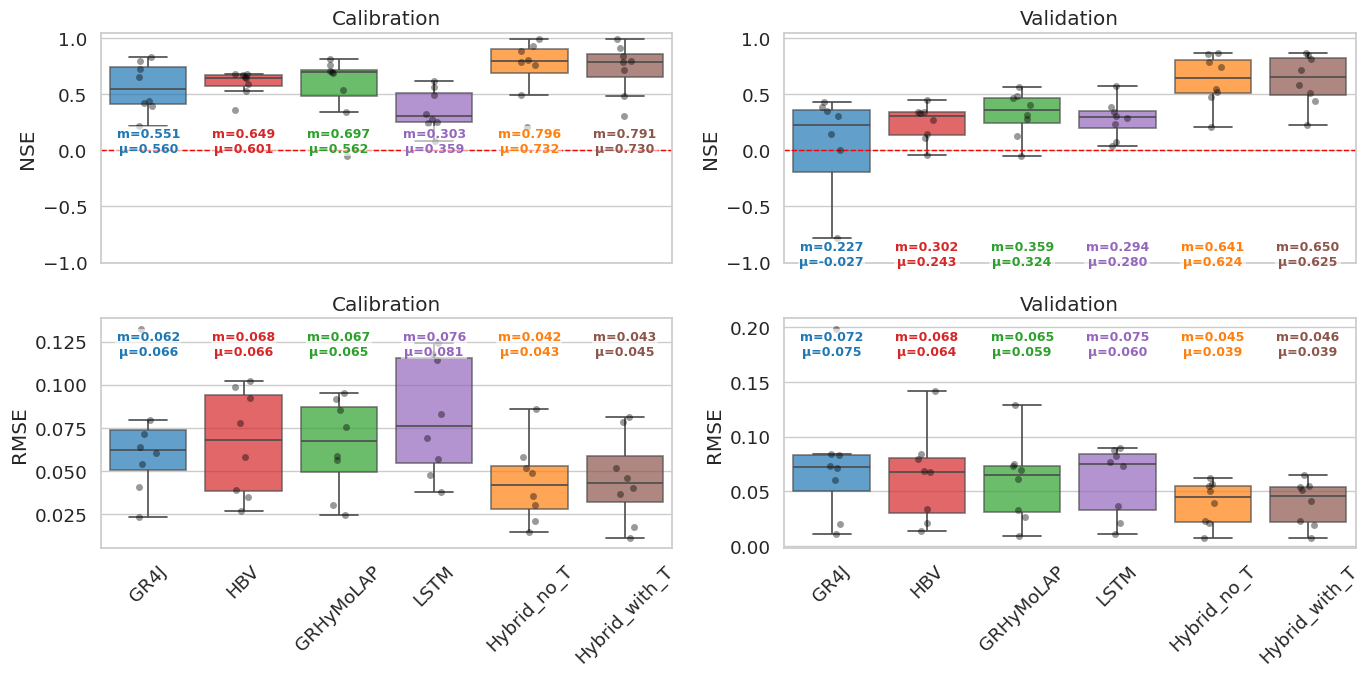

In [8]:
import seaborn as sns

# ==========================
# Model order
# ==========================
model_order = [
    "GR4J",
    "HBV",
    "GRHyMoLAP",
    "LSTM",
    "Hybrid_no_T",
    "Hybrid_with_T"
]

# colors
colors_list = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e', '#8c564b']
colors_dict = dict(zip(model_order, colors_list))

sns.set(style="whitegrid", font_scale=1.2)

# ==========================
# 2x2 Figure
# ==========================
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

metrics = [
    ('NSE_cal', 'Calibration'),
    ('NSE_val', 'Validation'),
    ('RMSE_cal', 'Calibration'),
    ('RMSE_val', 'Validation')
]

for i, (metric, col_title) in enumerate(metrics):

    ax = axes[i // 2, i % 2]

    # -------------------------
    # BOXPLOT
    # -------------------------
    sns.boxplot(
        x='Model',
        y=metric,
        data=metrics_df,
        order=model_order,
        showfliers=False,
        linewidth=1.2,
        ax=ax
    )

    # box coloring
    for patch, model in zip(ax.patches, model_order):
        patch.set_facecolor(colors_dict[model])
        patch.set_alpha(0.7)

    # stripplot
    sns.stripplot(
        x='Model',
        y=metric,
        data=metrics_df,
        order=model_order,
        color='black',
        alpha=0.4,
        jitter=True,
        ax=ax
    )

    # NSE = 0 reference line
    if "NSE" in metric:
        ax.axhline(0, color='red', linestyle='--', linewidth=1)

    # -------------------------
    # TITLES & AXES (FIXED)
    # -------------------------
    # column titles only
    ax.set_title(col_title)

    # row labels only
    if i < 2:
        ax.set_ylabel("NSE")
    else:
        ax.set_ylabel("RMSE")

    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

    # -------------------------
    # MEDIAN + MEAN
    # -------------------------
    ylim = ax.get_ylim()

    for j, model in enumerate(model_order):

        vals = metrics_df[metrics_df['Model'] == model][metric].dropna()

        if len(vals) == 0:
            continue

        median_val = np.median(vals)
        mean_val = np.mean(vals)

        # smart positioning
        if "NSE" in metric:
            y_coord = ylim[0] + 0.05 * (ylim[1] - ylim[0])
            va = 'bottom'
        else:
            y_coord = ylim[1] - 0.05 * (ylim[1] - ylim[0])
            va = 'top'

        ax.text(
            j,
            y_coord,
            f"m={median_val:.3f}\nμ={mean_val:.3f}",
            ha='center',
            va=va,
            fontsize=9,
            fontweight='bold',
            color=colors_dict[model],
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
        )

# ==========================
# Final adjustments
# ==========================
#plt.suptitle("Model performance over the 8 basins", fontsize=16, fontweight='bold')

# same NSE scale
axes[0,0].set_ylim(-1, 1.05)
axes[0,1].set_ylim(-1, 1.05)

plt.tight_layout()
plt.show()

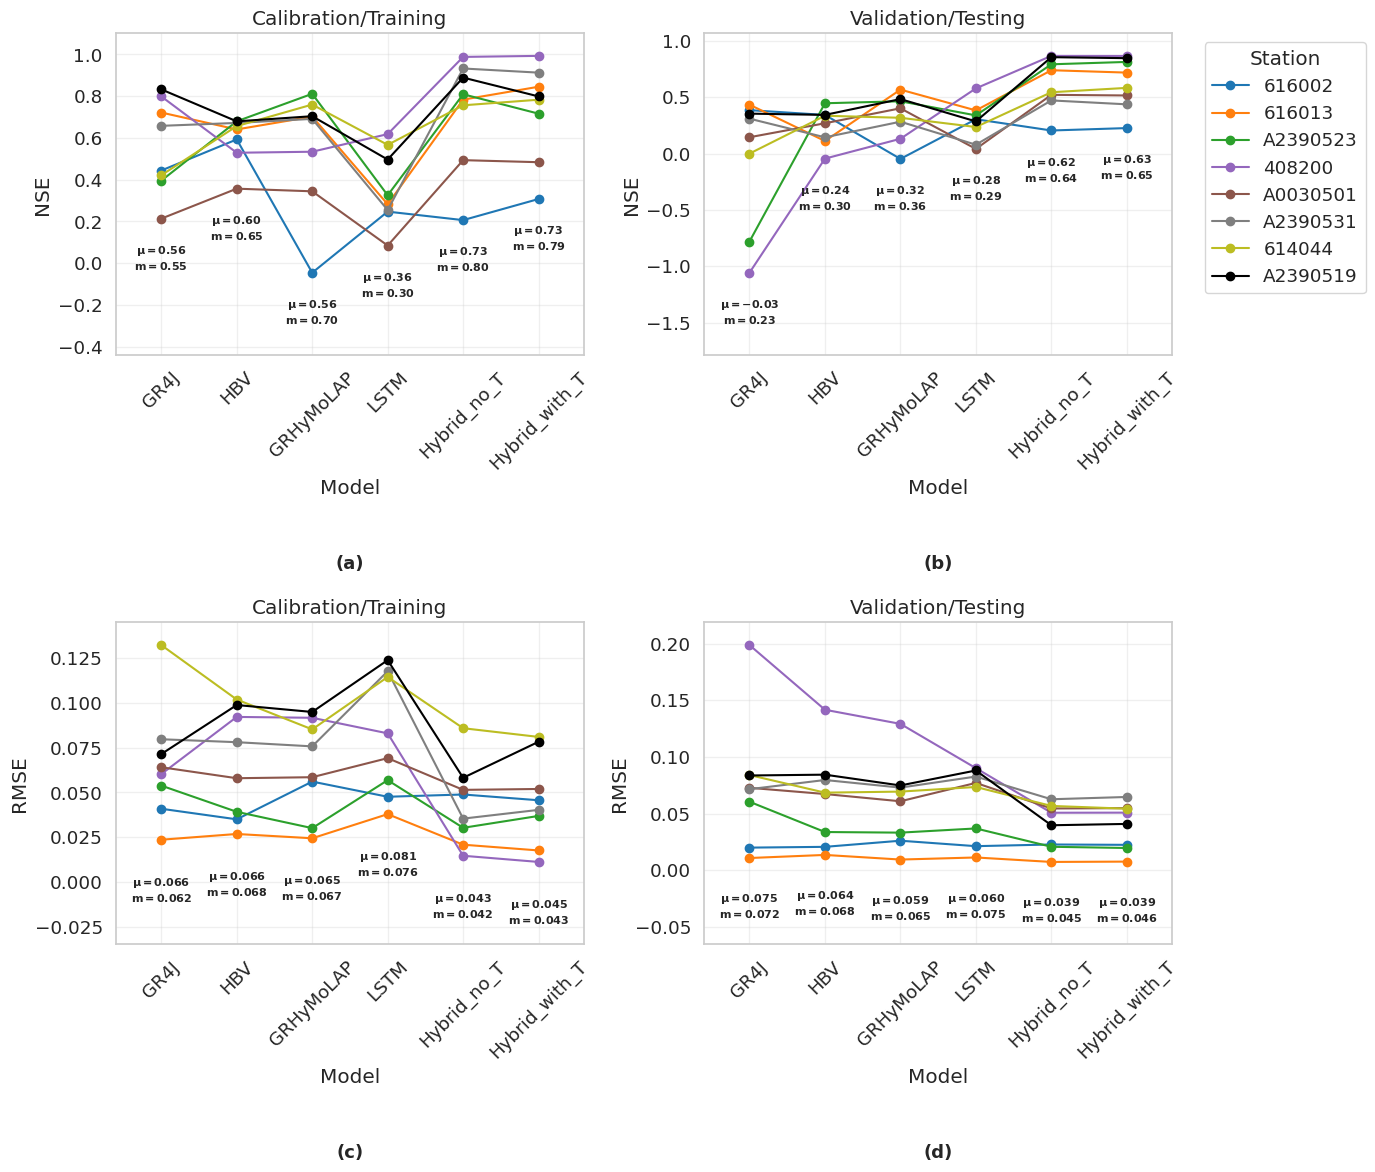

In [9]:
import matplotlib.pyplot as plt
import numpy as np

basin_order = ['616002', '616013', 'A2390523', '408200',
               'A0030501', 'A2390531', '614044', 'A2390519']

model_order = [m for m in models.keys() if m != "Qobs"]

def safe_get(df, model, basin, col):
    sub = df[(df["Model"] == model) & (df["Basin"] == basin)][col]
    return sub.values[0] if len(sub) > 0 else np.nan

# ==========================================================
# COLOR MAP (LAST BASIN BLACK)
# ==========================================================
default_colors = plt.cm.tab10(np.linspace(0, 1, len(basin_order)))

colors = {
    basin: default_colors[i] for i, basin in enumerate(basin_order)
}

# override last basin
colors[basin_order[-1]] = "black"

fig, axes = plt.subplots(2, 2, figsize=(14,12))

x = np.arange(len(model_order))

# ==========================================================
# PLOT NSE
# ==========================================================
for basin in basin_order:

    y_cal = [safe_get(metrics_df, model, basin, "NSE_cal") for model in model_order]
    y_val = [safe_get(metrics_df, model, basin, "NSE_val") for model in model_order]

    axes[0,0].plot(x, y_cal, marker='o', color=colors[basin], label=basin)
    axes[0,1].plot(x, y_val, marker='o', color=colors[basin], label=basin)

# ==========================================================
# PLOT RMSE
# ==========================================================
for basin in basin_order:

    y_cal = [safe_get(metrics_df, model, basin, "RMSE_cal") for model in model_order]
    y_val = [safe_get(metrics_df, model, basin, "RMSE_val") for model in model_order]

    axes[1,0].plot(x, y_cal, marker='o', color=colors[basin], label=basin)
    axes[1,1].plot(x, y_val, marker='o', color=colors[basin], label=basin)

# ==========================================================
# STYLE
# ==========================================================
titles = [["Calibration/Training", "Validation/Testing"],
          ["Calibration/Training", "Validation/Testing"]]

for i in range(2):
    for j in range(2):

        ax = axes[i, j]
        ax.set_title(titles[i][j])
        ax.set_xticks(x)
        ax.set_xticklabels(model_order, rotation=45)
        ax.grid(alpha=0.3)

        ax.set_xlim(-0.6, len(model_order) - 0.4)

        ax.set_xlabel("Model")
        ax.set_ylabel("NSE" if i == 0 else "RMSE")

        y_min, y_max = ax.get_ylim()
        ax.set_ylim(y_min - 0.30*(y_max - y_min), y_max + 0.05*(y_max - y_min))

# Legend only once
axes[0,1].legend(title="Station", bbox_to_anchor=(1.05, 1), loc='upper left')

# ==========================================================
# STATS (BOLD μ and med ONLY CHANGE)
# ==========================================================
for i, model in enumerate(model_order):

    cal_nse = [safe_get(metrics_df, model, basin, "NSE_cal") for basin in basin_order]
    val_nse = [safe_get(metrics_df, model, basin, "NSE_val") for basin in basin_order]

    cal_rmse = [safe_get(metrics_df, model, basin, "RMSE_cal") for basin in basin_order]
    val_rmse = [safe_get(metrics_df, model, basin, "RMSE_val") for basin in basin_order]

    axes[0,0].text(i, np.nanmin(cal_nse) - 0.12,
        r"$\mathbf{\mu = " + f"{np.nanmean(cal_nse):.2f}" + r"}$" + "\n" +
        r"$\mathbf{m = " + f"{np.nanmedian(cal_nse):.2f}" + r"}$",
        ha='center', va='top', fontsize=8)

    axes[0,1].text(i, np.nanmin(val_nse) - 0.22,
        r"$\mathbf{\mu = " + f"{np.nanmean(val_nse):.2f}" + r"}$" + "\n" +
        r"$\mathbf{m = " + f"{np.nanmedian(val_nse):.2f}" + r"}$",
        ha='center', va='top', fontsize=8)

    axes[1,0].text(i, np.nanmin(cal_rmse) - 0.02,
        r"$\mathbf{\mu = " + f"{np.nanmean(cal_rmse):.3f}" + r"}$" + "\n" +
        r"$\mathbf{m = " + f"{np.nanmedian(cal_rmse):.3f}" + r"}$",
        ha='center', va='top', fontsize=8)

    axes[1,1].text(i, np.nanmin(val_rmse) - 0.03,
        r"$\mathbf{\mu = " + f"{np.nanmean(val_rmse):.3f}" + r"}$" + "\n" +
        r"$\mathbf{m = " + f"{np.nanmedian(val_rmse):.3f}" + r"}$",
        ha='center', va='top', fontsize=8)

# ==========================================================
# SUBPLOT LABELS (a), (b), (c), (d)
# ==========================================================
labels = ['(a)', '(b)', '(c)', '(d)']


for ax, lab in zip(axes.flatten(), labels):
    ax.text(
        0.5, -0.62, lab,   # ↓ plus bas
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold',
        ha='center',
        va='top',
        clip_on=False
    )

plt.subplots_adjust(bottom=0.18, hspace=0.55)
plt.tight_layout()

plt.savefig(
    "perf.jpeg",
    dpi=700,
    bbox_inches="tight",
    facecolor="white"
)

#files.download("perf.jpeg")

plt.show()

In [10]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ==========================
# Parameters
# ==========================
basin_id = "A2390519"
plot_models = ["GR4J", "HBV", "GRHyMoLAP", "LSTM", "Hybrid_no_T", "Hybrid_with_T"]
colors_dict = {
    "GR4J": "#1f77b4",
    "HBV": "#8c564b",
    "GRHyMoLAP": "#2ca02c",
    "LSTM": "#9467bd",
    "Hybrid_no_T": "#ff7f0e",
    "Hybrid_with_T": "#d62728"
}

x_offset = 30  # number of empty days at the beginning

# ==========================
# Load data
# ==========================
file_pathP = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/P.xlsx"
P_val = pd.read_excel(file_pathP, sheet_name="Validation")[basin_id].values

# Obs_val and models must be defined before this code

# ==========================
# Prepare subplots
# ==========================
fig = make_subplots(
    rows=len(plot_models)+1, cols=1, shared_xaxes=True,
    vertical_spacing=0.03
)

# ==========================
# Precipitation (last 1095 days) with shift
# ==========================
P_last = np.array(P_val[-1095:]).flatten()
P_last_shifted = np.concatenate([np.full(x_offset, np.nan), P_last])
x_P = np.arange(len(P_last_shifted))

fig.add_trace(
    go.Bar(x=x_P, y=P_last_shifted, marker_color='black', name="Precipitation"),
    row=1, col=1
)
fig.update_yaxes(autorange='reversed', row=1, col=1, title_text="P (mm/d)")


# ==========================
# Loop over models with shift
# ==========================
obs_added = False  # to add Obs only once

for i, model_name in enumerate(plot_models):
    df_val = pd.read_excel(models[model_name], sheet_name="Validation")
    sim = df_val[basin_id].values
    if model_name in ["Hybrid_no_T", "Hybrid_with_T", "LSTM"]:
        sim[sim < 0] = 0
    obs = Obs_val[basin_id].values

    sim_last = sim[-1095:]
    obs_last = obs[-1095:]
    sim_last = np.where(np.isnan(obs_last), np.nan, sim_last)

    # Shift with NaN
    sim_last_shifted = np.concatenate([np.full(x_offset, np.nan), sim_last])
    obs_last_shifted = np.concatenate([np.full(x_offset, np.nan), obs_last])
    days_shifted = np.arange(len(sim_last_shifted))

    # Simulation
    fig.add_trace(
        go.Scatter(x=days_shifted, y=sim_last_shifted, mode='lines',
                   line=dict(color=colors_dict[model_name], width=2),
                   name=f"{model_name} sim"),
        row=i+2, col=1
    )

    # Observation (only once)
    if not obs_added:
        fig.add_trace(
            go.Scatter(x=days_shifted, y=obs_last_shifted, mode='lines',
                       line=dict(color='black', width=2),
                       name="Obs"),
            row=i+2, col=1
        )
        obs_added = True
    else:
        fig.add_trace(
            go.Scatter(x=days_shifted, y=obs_last_shifted, mode='lines',
                       line=dict(color='black', width=2),
                       showlegend=False),
            row=i+2, col=1
        )

    # Display Y title only for the 3rd model
    if i == 2:  # i starts at 0, so 2 = 3rd model
      fig.update_yaxes(title_text="Q (mm/d)", row=i+2, col=1)
    else:
      fig.update_yaxes(title_text="", row=i+2, col=1)

# ==========================
# Common X axis
# ==========================
xticks = [x_offset, 365 + x_offset, 730 + x_offset, 1095 + x_offset]
xticklabels = ["2012", "2013", "2014", "2015"]
fig.update_xaxes(title_text="Date", tickvals=xticks, ticktext=xticklabels,
                 row=len(plot_models)+1, col=1)

# ==========================
# Names at top right with larger size
# ==========================
fig.add_annotation(
    x=1, y=1.035, xref="paper", yref="paper",
    text="Precipitation", showarrow=False,
    font=dict(size=20, color="black"),  # increased size
    xanchor="right"
)

for i, model_name in enumerate(plot_models):
    fig.add_annotation(
        x=1, y=1-(i+1.25)*(1/(len(plot_models)+1)), xref="paper", yref="paper",
        text=model_name, showarrow=False,
        font=dict(size=20, color=colors_dict[model_name]),  # increased size
        xanchor="right"
    )

# ==========================
# General layout with larger titles and axes
# ==========================
fig.update_layout(
    title={
        'text': f"Station : {basin_id}",
        'x': 0.5,
        'y': 0.98,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=28)  # larger main title
    },
    width=1400,
    height=900,
    showlegend=False,
    template='plotly_white',
    font=dict(size=18)  # default size for axes and tick labels
)

# Y axes: increase title size
for i in range(len(plot_models)+1):
    fig.update_yaxes(title_font=dict(size=20), tickfont=dict(size=16), row=i+1, col=1)

# X axis: increase title and tick size
fig.update_xaxes(title_font=dict(size=20), tickfont=dict(size=16), row=len(plot_models)+1, col=1)

# ==========================
# Save and download the figure
# ==========================

fig.write_image("trajectory.jpeg",  scale=7)


# Download the file
#files.download("trajectory.jpeg")

# Display the figure
fig.show()

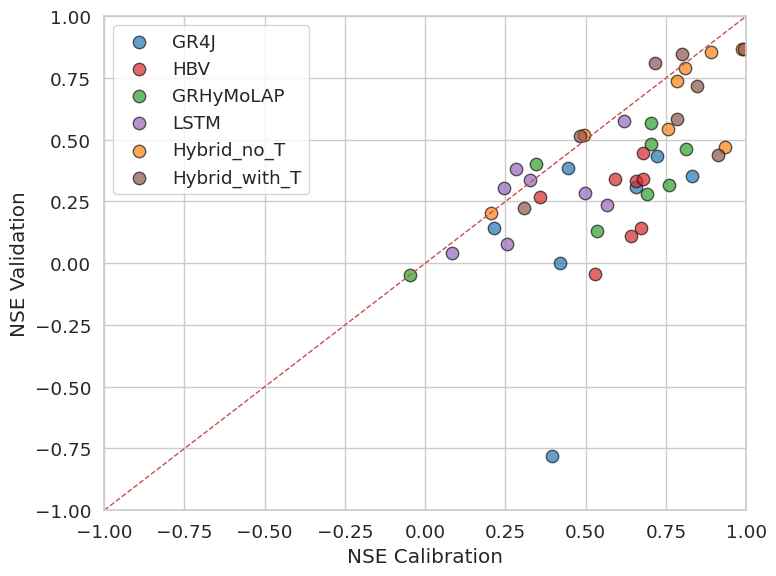

In [11]:
sns.set(style="whitegrid", font_scale=1.2)

# Model order and colors
model_order = [
    "GR4J",
    "HBV",
    "GRHyMoLAP",
    "LSTM",
    "Hybrid_no_T",
    "Hybrid_with_T"
]
colors_list = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e', '#8c564b']
colors_dict = dict(zip(model_order, colors_list))

# ==========================
# Scatter Calibration vs Validation (NSE only)
# ==========================
plt.figure(figsize=(8,6))
ax = plt.gca()

for model in model_order:
    df_model = metrics_df[metrics_df['Model'] == model]
    ax.scatter(
        df_model['NSE_cal'],
        df_model['NSE_val'],
        color=colors_dict[model],
        label=model,
        s=80,
        alpha=0.7,
        edgecolors='k'
    )

# y = x line
ax.plot([-1, 1], [-1, 1], 'r--', linewidth=1)

# axes and titles
ax.set_xlabel("NSE Calibration")
ax.set_ylabel("NSE Validation")
#ax.set_title("Calibration vs Validation (NSE)")
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.legend()

plt.tight_layout()
plt.savefig("NSE.jpeg", dpi=700)
#files.download("NSE.jpeg")
plt.show()

#Linear correlation for delay

In [12]:
# ==========================================================
# 🔧 Temporal memory & delayed response (P vs Q_obs)
# ==========================================================


# ==========================
# Load data
# ==========================
file_pathP = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/P.xlsx"
file_pathQ = file_path1  # your file containing Q_obs

P_cal = pd.read_excel(file_pathP, sheet_name="Calibration")
P_val = pd.read_excel(file_pathP, sheet_name="Validation")

Q_cal = pd.read_excel(file_pathQ, sheet_name="Calibration")
Q_val = pd.read_excel(file_pathQ, sheet_name="Validation")

# ==========================
# Significant basins
basins = ['616002', '616013', 'A2390523', '408200', 'A0030501', 'A2390531', '614044', 'A2390519']

# ==========================
# Cross-correlation function
# ==========================
def compute_lag(P, Q, max_lag=10):
    P = P - np.mean(P)
    Q = Q - np.mean(Q)

    corrs = []
    for lag in range(max_lag):
        if lag == 0:
            corr = np.corrcoef(P, Q)[0,1]
        else:
            corr = np.corrcoef(P[:-lag], Q[lag:])[0,1]
        corrs.append(corr)

    return np.argmax(corrs), np.max(corrs)

# ==========================
# Compute lags and correlations
# ==========================
lags_cal = []
lags_val = []
corrs_cal = []
corrs_val = []

for basin in basins:
    P_c = P_cal[basin].to_numpy()
    Q_c = Q_cal[basin].to_numpy()

    P_v = P_val[basin].to_numpy()
    Q_v = Q_val[basin].to_numpy()

    # NaN cleaning
    mask_c = ~np.isnan(P_c) & ~np.isnan(Q_c)
    mask_v = ~np.isnan(P_v) & ~np.isnan(Q_v)

    lag_c, corr_c = compute_lag(P_c[mask_c], Q_c[mask_c])
    lag_v, corr_v = compute_lag(P_v[mask_v], Q_v[mask_v])

    lags_cal.append(lag_c)
    lags_val.append(lag_v)
    corrs_cal.append(corr_c)
    corrs_val.append(corr_v)

# ==========================
# Global statistics
# ==========================
mean_cal = np.mean(lags_cal)
std_cal = np.std(lags_cal)
mean_val = np.mean(lags_val)
std_val = np.std(lags_val)

print("=== Temporal memory & delayed response (only lags giving highest correlations) ===")

# Display basins and correlations
for i, basin in enumerate(basins):
    print(f"{basin}: lag_cal={lags_cal[i]}, corr_cal={corrs_cal[i]:.3f} | "
          f"lag_val={lags_val[i]}, corr_val={corrs_val[i]:.3f}")

=== Temporal memory & delayed response (only lags giving highest correlations) ===
616002: lag_cal=2, corr_cal=0.301 | lag_val=2, corr_val=0.276
616013: lag_cal=1, corr_cal=0.336 | lag_val=2, corr_val=0.323
A2390523: lag_cal=2, corr_cal=0.195 | lag_val=2, corr_val=0.211
408200: lag_cal=2, corr_cal=0.387 | lag_val=2, corr_val=0.428
A0030501: lag_cal=1, corr_cal=0.066 | lag_val=1, corr_val=0.072
A2390531: lag_cal=4, corr_cal=0.200 | lag_val=5, corr_val=0.201
614044: lag_cal=1, corr_cal=0.390 | lag_val=1, corr_val=0.360
A2390519: lag_cal=2, corr_cal=0.306 | lag_val=2, corr_val=0.333


# Use the same lags to compute the correlation for models

In [13]:
# ==========================================================
# 🔧 Temporal memory & delayed response (FINAL VERSION)
# ==========================================================

# ==========================
# Parameters
# ==========================
basins = ['616002', '616013', 'A2390523', '408200',
          'A0030501', 'A2390531', '614044', 'A2390519']

# Real lags (to be applied as in GR4J)
real_lags_cal = {'616002': 2, '616013': 1, 'A2390523': 2, '408200': 2,
                 'A0030501': 1, 'A2390531': 4, '614044': 1, 'A2390519': 2}
real_lags_val = {'616002': 2, '616013': 2, 'A2390523': 2, '408200': 2,
                 'A0030501': 1, 'A2390531': 5, '614044': 1, 'A2390519': 2}

models = {
    "GR4J": file_path2,
    "HBV": file_path3,
    "GRHyMoLAP": file_path4,
    "LSTM": file_path5,
    "Hybrid_no_T": file_path6,
    "Hybrid_with_T": file_path7
}

file_pathP = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/P.xlsx"

# ==========================
# Load P
# ==========================
P_cal = pd.read_excel(file_pathP, sheet_name="Calibration")[basins]
P_val = pd.read_excel(file_pathP, sheet_name="Validation")[basins]

# ==========================
# Robust function
# ==========================
def compute_corr(P, Q, lag):
    if lag >= len(Q):
        return np.nan

    # Alignment
    P_aligned = P[:-lag] if lag > 0 else P.copy()
    Q_aligned = Q[lag:]  if lag > 0 else Q.copy()

    # NaN cleaning
    mask = ~np.isnan(P_aligned) & ~np.isnan(Q_aligned)

    if np.sum(mask) < 5:
        return np.nan

    return np.corrcoef(P_aligned[mask], Q_aligned[mask])[0,1]

# ==========================
# Computation
# ==========================
results = []

for model_name, file_path in models.items():

    Q_cal_full = pd.read_excel(file_path, sheet_name="Calibration")[basins]
    Q_val_full = pd.read_excel(file_path, sheet_name="Validation")[basins]

    is_lstm = model_name in ["LSTM", "Hybrid_no_T", "Hybrid_with_T"]

    for basin in basins:

        P_c = P_cal[basin].to_numpy()
        P_v = P_val[basin].to_numpy()

        Q_c = Q_cal_full[basin].to_numpy()
        Q_v = Q_val_full[basin].to_numpy()

        # LSTM alignment
        if is_lstm:
            P_c = P_c[5:]
            P_v = P_v[5:]
            Q_c[Q_c < 0] = 0
            Q_v[Q_v < 0] = 0

        lag_c = real_lags_cal[basin]
        lag_v = real_lags_val[basin]

        corr_cal = compute_corr(P_c, Q_c, lag_c)
        corr_val = compute_corr(P_v, Q_v, lag_v)

        results.append({
            "Basin": basin,
            "Model": model_name,
            "Lag_cal": lag_c,
            "Corr_cal": corr_cal,
            "Lag_val": lag_v,
            "Corr_val": corr_val
        })

# ==========================
# Final DataFrame
# ==========================
df_corr = pd.DataFrame(results)
print(df_corr)

       Basin          Model  Lag_cal  Corr_cal  Lag_val  Corr_val
0     616002           GR4J        2  0.466532        2  0.377721
1     616013           GR4J        1  0.470333        2  0.415821
2   A2390523           GR4J        2  0.307607        2  0.297884
3     408200           GR4J        2  0.428491        2  0.419730
4   A0030501           GR4J        1  0.064739        1  0.145472
5   A2390531           GR4J        4  0.246255        5  0.185252
6     614044           GR4J        1  0.303540        1  0.285347
7   A2390519           GR4J        2  0.394540        2  0.458389
8     616002            HBV        2  0.244649        2  0.283689
9     616013            HBV        1  0.255654        2  0.159035
10  A2390523            HBV        2  0.220057        2  0.255926
11    408200            HBV        2  0.261765        2  0.367303
12  A0030501            HBV        1  0.064445        1  0.180652
13  A2390531            HBV        4  0.181826        5  0.100900
14    6140

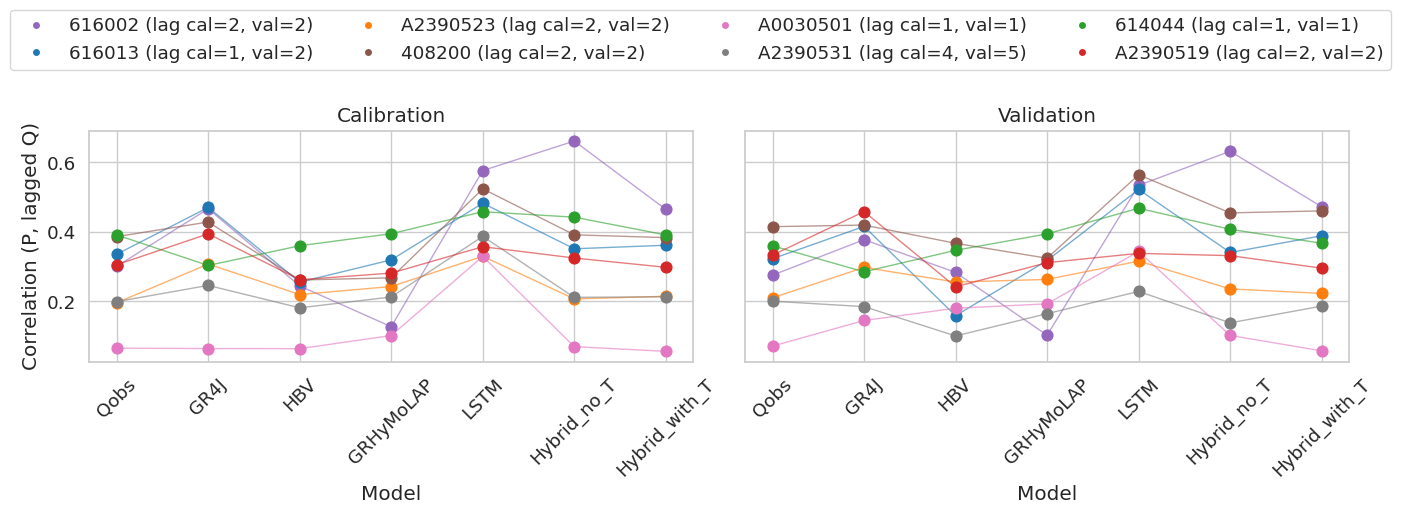

In [14]:
# ==========================================================
# 🔧 Temporal memory & delayed response: basin-wise points + segments (lags in legend)
# ==========================================================


# ==========================
# Basins
# ==========================
basins = ['616002', '616013', 'A2390523', '408200',
          'A0030501', 'A2390531', '614044', 'A2390519']

# Real lags
real_lags_cal = {'616002': 2, '616013': 1, 'A2390523': 2, '408200': 2,
                 'A0030501': 1, 'A2390531': 4, '614044': 1, 'A2390519': 2}
real_lags_val = {'616002': 2, '616013': 2, 'A2390523': 2, '408200': 2,
                 'A0030501': 1, 'A2390531': 5, '614044': 1, 'A2390519': 2}

# Models
models = {
    "Qobs": None,
    "GR4J": file_path2,
    "HBV": file_path3,
    "GRHyMoLAP": file_path4,
    "LSTM": file_path5,
    "Hybrid_no_T": file_path6,
    "Hybrid_with_T": file_path7
}

# P files
file_pathP = "/content/drive/MyDrive/Colab Notebooks/Coupling/Draft_on DeepGRHyMoLAP/Predicted_series/P.xlsx"
P_cal = pd.read_excel(file_pathP, sheet_name="Calibration")[basins]
P_val = pd.read_excel(file_pathP, sheet_name="Validation")[basins]

# ==========================
# Correlation function
# ==========================
def compute_corr(P, Q, lag):
    if lag >= len(Q):
        return np.nan
    P_aligned = P[:-lag] if lag > 0 else P.copy()
    Q_aligned = Q[lag:]  if lag > 0 else Q.copy()

    mask = ~np.isnan(P_aligned) & ~np.isnan(Q_aligned)
    if np.sum(mask) < 2:
        return np.nan
    return np.corrcoef(P_aligned[mask], Q_aligned[mask])[0,1]

# ==========================
# Basin colors
# ==========================
colors = {
    '616002': '#9467bd',
    '616013': '#1f77b4',
    'A2390523': '#ff7f0e',
    '408200': '#8c564b',
    'A0030501': '#e377c2',
    'A2390531': '#7f7f7f',
    '614044': '#2ca02c',
    'A2390519': '#d62728'
}

# ==========================
# Computation
# ==========================
results = []

for model_name, file_path in models.items():
    for basin in basins:
        P_c = P_cal[basin].to_numpy()
        P_v = P_val[basin].to_numpy()

        if model_name == "Qobs":
            Q_c = pd.read_excel(file_path1, sheet_name="Calibration")[basin].to_numpy()
            Q_v = pd.read_excel(file_path1, sheet_name="Validation")[basin].to_numpy()
            is_lstm = False
        else:
            Q_cal_full = pd.read_excel(file_path, sheet_name="Calibration")[basins]
            Q_val_full = pd.read_excel(file_path, sheet_name="Validation")[basins]
            Q_c = Q_cal_full[basin].to_numpy()
            Q_v = Q_val_full[basin].to_numpy()
            is_lstm = model_name in ["LSTM", "Hybrid_no_T", "Hybrid_with_T"]
            if is_lstm:
                P_c = P_c[5:]
                P_v = P_v[5:]
                Q_c[Q_c < 0] = 0
                Q_v[Q_v < 0] = 0

        lag_c = real_lags_cal[basin]
        lag_v = real_lags_val[basin]

        corr_cal = compute_corr(P_c, Q_c, lag_c)
        corr_val = compute_corr(P_v, Q_v, lag_v)

        results.append({
            "Basin": basin,
            "Model": model_name,
            "Lag_cal": lag_c,
            "Corr_cal": corr_cal,
            "Lag_val": lag_v,
            "Corr_val": corr_val
        })

df_corr = pd.DataFrame(results)
model_order = list(models.keys())

# ==========================
# Plot (no lag shown on figure)
# ==========================
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

for ax, col in zip(axes, ['Corr_cal', 'Corr_val']):
    for basin in basins:
        subset = df_corr[df_corr["Basin"] == basin].set_index("Model").reindex(model_order)
        x = range(len(model_order))
        y = subset[col].values

        ax.plot(x, y, color=colors[basin], linewidth=1, alpha=0.6)
        ax.scatter(x, y, color=colors[basin], s=60, zorder=3)

    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(model_order, rotation=45)
    ax.set_xlabel("Model")  # ✅ added
    ax.grid(True)
    ax.set_title("Calibration" if col=='Corr_cal' else "Validation")

    if col=='Corr_cal':
        ax.set_ylabel("Correlation (P, lagged Q)")

# ==========================
# Legend with lags
# ==========================
labels = [
    f"{b} (lag cal={real_lags_cal[b]}, val={real_lags_val[b]})"
    for b in basins
]

handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=colors[b], markersize=6)
    for b in basins
]

fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout(rect=[0,0,1,0.88])
plt.show()

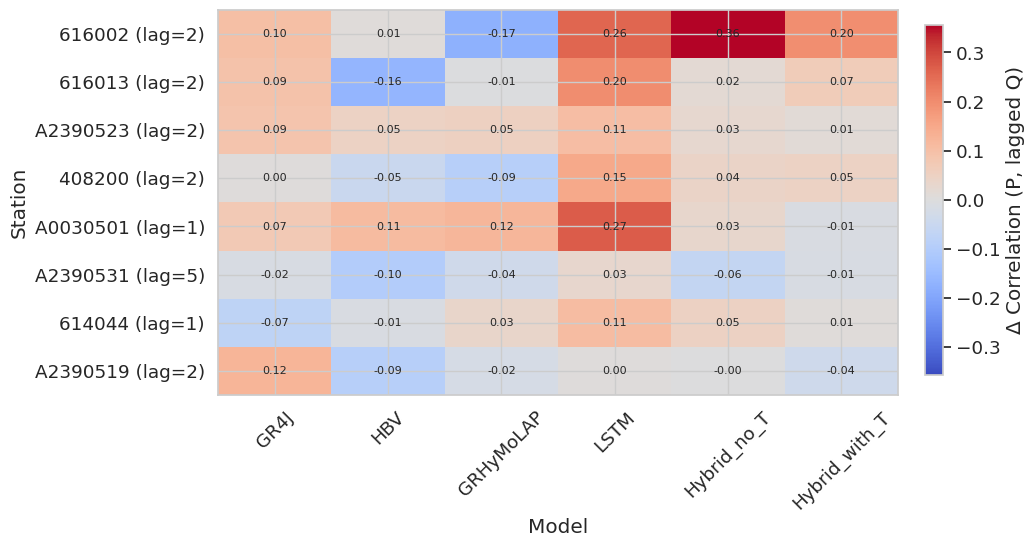

In [15]:
# ==========================================================
# 🔥 HEATMAP: Δ Correlation vs observed (VALIDATION ONLY)
# ==========================================================


# --------------------------
# 1. OBS correlation (VALIDATION)
# --------------------------
obs_rows = []

for basin in basins:

    P_v = P_val[basin].to_numpy()
    Q_obs_v = pd.read_excel(file_path1, sheet_name="Validation")[basin].to_numpy()

    lag_v = real_lags_val[basin]

    obs_rows.append({
        "Basin": basin,
        "Corr_obs_val": compute_corr(P_v, Q_obs_v, lag_v)
    })

df_obs = pd.DataFrame(obs_rows)

# --------------------------
# 2. Merge models + obs
# --------------------------
df = df_corr.merge(df_obs, on="Basin")

# --------------------------
# 3. Δ correlation + score
# --------------------------
df["Corr_diff_val"] = df["Corr_val"] - df["Corr_obs_val"]   # signed
df["Score_val"] = np.abs(df["Corr_diff_val"])               # distance

# --------------------------
# 4. MATRIX (Δ correlation)
# --------------------------
models_only = [m for m in models.keys() if m != "Qobs"]

diff_matrix_val = pd.DataFrame(index=basins, columns=models_only)

for basin in basins:
    sub = df[df["Basin"] == basin]

    for m in models_only:
        diff_matrix_val.loc[basin, m] = sub[sub["Model"] == m]["Corr_diff_val"].values[0]

diff_matrix_val = diff_matrix_val.astype(float)

# --------------------------
# 5. Add lag info (OPTIONAL but recommended)
# --------------------------
diff_matrix_val.index = [
    f"{b} (lag={real_lags_val[b]})"
    for b in diff_matrix_val.index
]

# --------------------------
# 6. Plot heatmap
# --------------------------
fig, ax = plt.subplots(figsize=(9,5))

# symmetry around 0 (CRUCIAL)
vmax = np.max(np.abs(diff_matrix_val.values))

im = ax.imshow(
    diff_matrix_val,
    aspect="auto",
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax
)

# ticks
ax.set_xticks(range(len(models_only)))
ax.set_xticklabels(models_only, rotation=45)
ax.set_yticks(range(len(diff_matrix_val.index)))
ax.set_yticklabels(diff_matrix_val.index)

# annotations (values in each cell)
for i in range(diff_matrix_val.shape[0]):
    for j in range(diff_matrix_val.shape[1]):
        val = diff_matrix_val.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

# clean colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Δ Correlation (P, lagged Q)")

# labels
ax.set_xlabel("Model")
ax.set_ylabel("Station")

plt.savefig(
    "correlation.jpeg",
    dpi=700,
    bbox_inches="tight",
    facecolor="white"
)

#files.download("correlation.jpeg")
plt.show()

# Dry days and Precipitation days with or without Response

## This is the case where P>0. It can be changed easily into to the case of P=0

In [16]:
# ==========================================================
# 🔧 Rainfall-response fidelity (P > 0 ONLY, OBS-defined response)
# ==========================================================
import numpy as np
import pandas as pd

Q_obs_val = pd.read_excel(file_path1, sheet_name="Validation")[basins]
P_val = pd.read_excel(file_pathP, sheet_name="Validation")[basins]

results_rain = []

for model_name, file_path in models.items():
    for basin in basins:

        P_v = P_val[basin].to_numpy()
        Q_obs_v = Q_obs_val[basin].to_numpy()

        # --------------------------
        # model series
        # --------------------------
        if model_name == "Qobs":
            Q_v = Q_obs_v.copy()
        else:
            Q_val_full = pd.read_excel(file_path, sheet_name="Validation")[basins]
            Q_v = Q_val_full[basin].to_numpy()

            if model_name in ["LSTM", "Hybrid_no_T", "Hybrid_with_T"]:
                P_v = P_v[5:]
                Q_obs_v = Q_obs_v[5:]
                Q_v[Q_v < 0] = 0

        # --------------------------
        # rainfall condition
        # --------------------------
        rain_mask = P_v[1:] > 0

        dQ_obs = Q_obs_v[1:] - Q_obs_v[:-1]
        dQ_mod = Q_v[1:] - Q_v[:-1]

        dQ_obs_rain = dQ_obs[rain_mask]
        dQ_mod_rain = dQ_mod[rain_mask]

        # --------------------------
        # response segments (OBS-defined)
        # --------------------------
        mask_rise = dQ_obs_rain > 0
        mask_fall = dQ_obs_rain <= 0


        def fidelity(mask):

            if np.sum(mask) < 2:
                return np.nan

            obs_seg = dQ_obs_rain[mask]
            mod_seg = dQ_mod_rain[mask]

            # 🔴 REMOVE NaNs HERE
            valid_mask = (~np.isnan(obs_seg)) & (~np.isnan(mod_seg))

            if np.sum(valid_mask) == 0:
                return np.nan

            return np.mean(
                np.sign(mod_seg[valid_mask]) ==
                np.sign(obs_seg[valid_mask])
            )

        results_rain.append({
            "Basin": basin,
            "Model": model_name,
            "F_rise": fidelity(mask_rise),
            "F_fall": fidelity(mask_fall)
        })

df_rain = pd.DataFrame(results_rain)



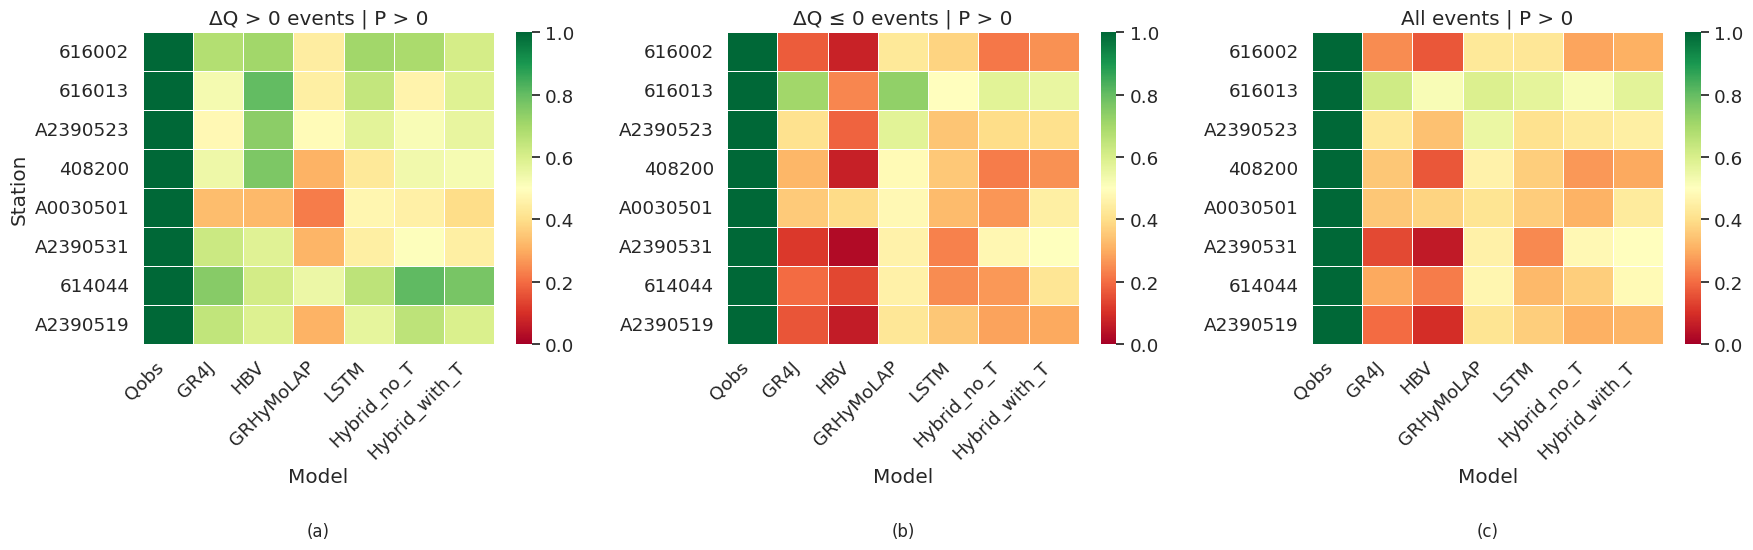

In [17]:
basin_order = ['616002', '616013', 'A2390523', '408200',
               'A0030501', 'A2390531', '614044', 'A2390519']

# ==========================================================
# 🔧 RECOMPUTE TOTAL NON-VIOLATION (CORRECT WAY)
# ==========================================================
results_total = []

Q_obs_val = pd.read_excel(file_path1, sheet_name="Validation")[basins]

for model_name, file_path in models.items():
    for basin in basins:

        P_v = P_val[basin].to_numpy()
        Q_obs_v = Q_obs_val[basin].to_numpy()

        # --------------------------
        # model series
        # --------------------------
        if model_name == "Qobs":
            Q_v = Q_obs_v.copy()
        else:
            Q_val_full = pd.read_excel(file_path, sheet_name="Validation")[basins]
            Q_v = Q_val_full[basin].to_numpy()

            if model_name in ["LSTM", "Hybrid_no_T", "Hybrid_with_T"]:
                P_v = P_v[5:]
                Q_obs_v = Q_obs_v[5:]
                Q_v[Q_v < 0] = 0

        # --------------------------
        # ΔQ
        # --------------------------
        dQ_obs = Q_obs_v[1:] - Q_obs_v[:-1]
        dQ_mod = Q_v[1:] - Q_v[:-1]

        # --------------------------
        # P > 0 condition
        # --------------------------
        rain_mask = P_v[1:] > 0

        dQ_obs_rain = dQ_obs[rain_mask]
        dQ_mod_rain = dQ_mod[rain_mask]

        # --------------------------
        # TOTAL NON-VIOLATION (TRUE DEFINITION + NaN SAFE)
        # --------------------------
        if len(dQ_obs_rain) < 2:
          total = np.nan
        else:
           # masque valide (ignore NaN dans obs et model)
           valid_mask = (
            ~np.isnan(dQ_obs_rain) &
            ~np.isnan(dQ_mod_rain)
          )

           if np.sum(valid_mask) == 0:
             total = np.nan
           else:
             total = np.sum(
             np.sign(dQ_mod_rain[valid_mask]) ==
             np.sign(dQ_obs_rain[valid_mask])
             ) / np.sum(valid_mask)

        results_total.append({
            "Basin": basin,
            "Model": model_name,
            "F_total": total
        })

df_total = pd.DataFrame(results_total)

# ==========================================================
# Pivot tables (existing + new)
# ==========================================================
pivot_rise = df_rain.pivot(index="Basin", columns="Model", values="F_rise")
pivot_fall = df_rain.pivot(index="Basin", columns="Model", values="F_fall")
pivot_total = df_total.pivot(index="Basin", columns="Model", values="F_total")

# impose order
pivot_rise = pivot_rise.reindex(index=basin_order, columns=model_order)
pivot_fall = pivot_fall.reindex(index=basin_order, columns=model_order)
pivot_total = pivot_total.reindex(index=basin_order, columns=model_order)


# ==========================================================
# GRID (3 columns)
# ==========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

ax1, ax2, ax3 = axes

# --------------------------
# Rise
# --------------------------
sns.heatmap(
    pivot_rise,
    vmin=0, vmax=1,
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    ax=ax1
)

ax1.set_title("ΔQ > 0 events | P > 0")
ax1.set_xlabel("Model")
ax1.set_ylabel("Station")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# --------------------------
# Fall
# --------------------------
sns.heatmap(
    pivot_fall,
    vmin=0, vmax=1,
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    ax=ax2
)

ax2.set_title("ΔQ ≤ 0 events | P > 0")
ax2.set_xlabel("Model")
ax2.set_ylabel("")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")

# --------------------------
# TOTAL NON-VIOLATION
# --------------------------
sns.heatmap(
    pivot_total,
    vmin=0, vmax=1,
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    ax=ax3
)

ax3.set_title("All events | P > 0")
ax3.set_xlabel("Model")
ax3.set_ylabel("")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha="right")

# --------------------------
# a, b, c labels (BOTTOM)
# --------------------------
for i, ax in enumerate(axes):
    ax.text(
        0.5, -0.6,
        f"({chr(97+i)})",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=12
    )

# --------------------------
# Layout
# --------------------------
plt.subplots_adjust(bottom=0.02)
plt.tight_layout()

plt.savefig(
    "rainfall_response.jpeg",
    dpi=700,
    bbox_inches="tight",
    facecolor="white"
)
#files.download("rainfall_response.jpeg")
plt.show()

##Observed responses

      Basin    P>0 ΔQ+   P>0 ΔQ≤0    P=0 ΔQ+   P=0 ΔQ≤0
0    616002  14.867065  85.132935   0.903614  99.096386
1    616013  49.156777  50.843223  23.858550  76.141450
2  A2390523  27.817048  72.182952   9.551986  90.448014
3    408200  14.163498  85.836502   6.893382  93.106618
4  A0030501  24.095360  75.904640  16.621803  83.378197
5  A2390531   5.223881  94.776119   1.685731  98.314269
6    614044  18.192090  81.807910   1.016949  98.983051
7  A2390519   6.556684  93.443316   2.501787  97.498213


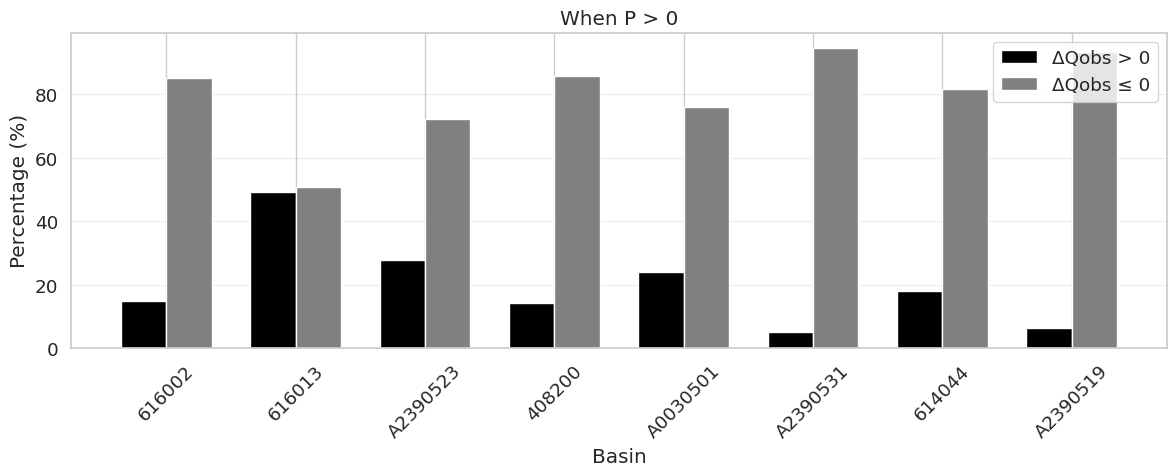

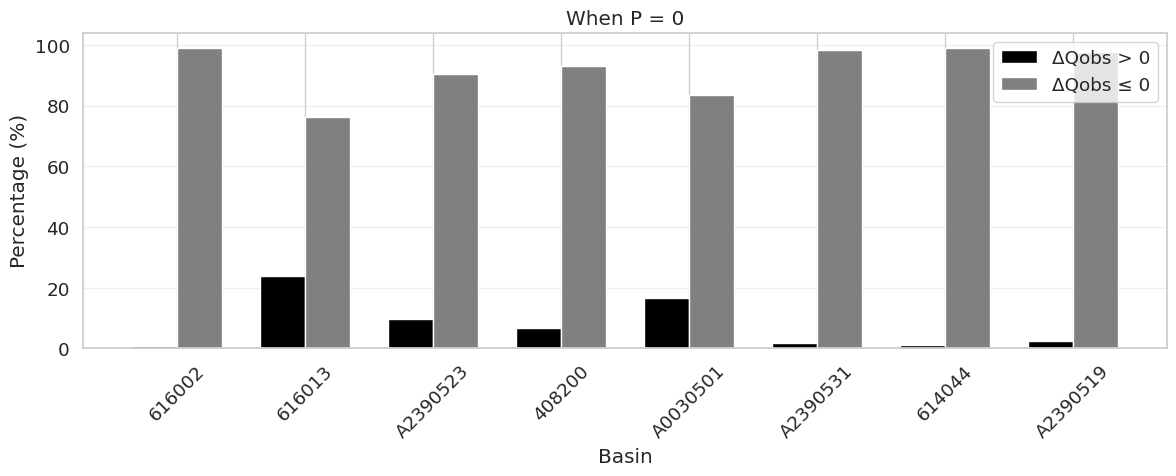

In [18]:
basin_order = ['616002', '616013', 'A2390523', '408200',
               'A0030501', 'A2390531', '614044', 'A2390519']

results = []

# ==========================================================
# COMPUTE FROM RAW SERIES (P, Q_obs)
# ==========================================================
for basin in basin_order:

    P = P_val[basin].to_numpy()
    Q = Q_obs_val[basin].to_numpy()

    dQ = Q[1:] - Q[:-1]
    P_shift = P[1:]

    # ==========================================================
    # P > 0
    # ==========================================================
    mask_p_pos = P_shift > 0
    dQ_pos = dQ[mask_p_pos]

    valid_pos = ~np.isnan(dQ_pos)

    if np.any(valid_pos):
        pos_pos = 100 * np.sum(dQ_pos[valid_pos] > 0) / np.sum(valid_pos)
        neg_pos = 100 * np.sum(dQ_pos[valid_pos] <= 0) / np.sum(valid_pos)
    else:
        pos_pos = neg_pos = np.nan

    # ==========================================================
    # P = 0
    # ==========================================================
    mask_p_zero = P_shift == 0
    dQ_zero = dQ[mask_p_zero]

    valid_zero = ~np.isnan(dQ_zero)

    if np.any(valid_zero):
        pos_zero = 100 * np.sum(dQ_zero[valid_zero] > 0) / np.sum(valid_zero)
        neg_zero = 100 * np.sum(dQ_zero[valid_zero] <= 0) / np.sum(valid_zero)
    else:
        pos_zero = neg_zero = np.nan

    # ✅ IMPORTANT: always append
    results.append([basin, pos_pos, neg_pos, pos_zero, neg_zero])

# ==========================================================
# DATAFRAME
# ==========================================================
df_plot = pd.DataFrame(
    results,
    columns=["Basin", "P>0 ΔQ+", "P>0 ΔQ≤0", "P=0 ΔQ+", "P=0 ΔQ≤0"]
)

# 🔍 Debug (to remove after verification)
print(df_plot)

# ==========================================================
# OPTION: do not remove all NaNs
# ==========================================================
# df_plot = df_plot.dropna()  # ❌ dangerous
df_plot = df_plot.dropna(how='all')  # ✅ safer

models = df_plot["Basin"].values
x = np.arange(len(models))
width = 0.35

# ==========================================================
# FIGURE 1: P > 0
# ==========================================================
fig1, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(x - width/2,
        df_plot["P>0 ΔQ+"],
        width,
        label="ΔQobs > 0",
        color="black")

ax1.bar(x + width/2,
        df_plot["P>0 ΔQ≤0"],
        width,
        label="ΔQobs ≤ 0",
        color="gray")

ax1.set_title("When P > 0")
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45)
ax1.set_ylabel("Percentage (%)")
ax1.set_xlabel("Basin")
ax1.grid(axis="y", alpha=0.3)
ax1.legend()

plt.tight_layout()
plt.savefig(
    "O_rainfall_response.jpeg",
    dpi=700,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

# ==========================================================
# FIGURE 2: P = 0
# ==========================================================
fig2, ax2 = plt.subplots(figsize=(12, 5))

ax2.bar(x - width/2,
        df_plot["P=0 ΔQ+"],
        width,
        label="ΔQobs > 0",
        color="black")

ax2.bar(x + width/2,
        df_plot["P=0 ΔQ≤0"],
        width,
        label="ΔQobs ≤ 0",
        color="gray")

ax2.set_title("When P = 0")
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45)
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Basin")
ax2.grid(axis="y", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig(
    "D_rainfall_response.jpeg",
    dpi=700,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()